# Isolation Forest - Detecção de Anomalias

Após clustering, os dados serão processados para detectar anomalias isoladas, ajustando contamination (0,05–0,1) com base na análise exploratória. 

O algoritmo identificará picos de contaminação (ex.: fósforo elevado), focando em eventos críticos. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pcj.utils import BASE_DIR, dados

In [3]:
# Dados para testes

dados_limpos, metadados, variaveis = dados(r"data\processed\dados_limpos.xlsx")

X = dados_limpos.copy()

In [3]:
# Verificações

# print(dados_limpos['Data'].dtype, end='')
# print(dados_limpos['data_normalizada'].dtype)
# print(dados_limpos.columns)
# print(variaveis)
print(dados_limpos[variaveis])

       COR  TURB.   pH  ALC.   AC.  O.C.  O.D.    Cl  DUR.     Fe    Mn  \
0    200.0   64.0  7.0  29.0   3.0   6.3   2.0  16.0  36.0   3.23  0.09   
1    432.0  131.0  7.2  34.0   5.0   6.8   3.5  23.0  47.0   6.26  0.17   
2    690.0  241.0  7.4  38.0   8.0   7.5   4.8  33.0  66.0  11.20  0.32   
3    393.0   72.0  6.5  29.0   6.0   5.9   2.8  20.0  30.0   6.82  0.08   
4    868.0  238.0  7.1  31.0   7.0   7.2   4.1  21.0  33.0   9.55  0.12   
..     ...    ...  ...   ...   ...   ...   ...   ...   ...    ...   ...   
571  217.0  134.0  7.5  48.0   9.0   9.7   4.2  39.0  63.0   1.57  0.11   
572  805.0  746.0  7.8  60.0  18.0  17.6   6.0  45.0  96.0   2.80  0.19   
573    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
574    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
575    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   

     Cond.  Cianobacteria     C.F.  Clorofila     F  
0    131.0         6600.0  23000.0       2.23

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### 01 - Minha Tentativa

In [4]:
from sklearn.ensemble import IsolationForest

X = dados_limpos[variaveis].copy()

isf = IsolationForest(contamination=0.05).fit(X)

isf.predict(X)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1,
        1,  1, -1,  1, -1, -1,  1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### 02 - Seguindo Tutorial

Link para o tutorial:
https://medium.com/datarisk-io/detec%C3%A7%C3%A3o-de-anomalias-usando-o-isolation-forest-5d29728fb255

Na verdade, o tutorial não deixa muito claro como executar as etapas que ele lista, vou tomar uma liberdade poética.

In [5]:
# Estabelecendo as regras do algoritmo (acho)
from sklearn.ensemble import IsolationForest

iFo = IsolationForest(contamination=0.05,   # No projeto, queremos testar esse valor de 0,05 a 0,1
                      random_state=42       # É o valor usado no tutorial, e percebo que ele é frequentemente usado. Imagino que seja um padrão por conta do Hitchiker's Guide to the Galaxy       
                      )

In [6]:
# Rótulos binários (mais parecido com o tutorial)

rotulos = iFo.fit_predict(dados_limpos[variaveis])   # Faz o fit e classificação, gerando rótulos binários (-1 e 1)

outliers = dados_limpos[rotulos == -1]

outliers

,Index,Data,data_normalizada,Estatistica,COR,TURB.,pH,ALC.,AC.,O.C.,O.D.,Cl,DUR.,Fe,Mn,Cond.,Cianobacteria,C.F.,Clorofila,F
35,35,2009-12-01,2009-12-01,Max.,1650.0,970.0,7.3,39.0,10.0,11.2,5.7,23.0,40.0,26.00,0.25,154.0,3497.0,140000.0,29.02,0.19
74,74,2011-01-01,2011-01-01,Max.,810.0,677.0,7.4,32.0,6.0,17.6,7.0,35.0,54.0,12.15,0.80,170.0,354.0,30000.0,2.23,0.21
107,107,2011-12-01,2011-12-01,Max.,1176.0,1128.0,7.8,56.0,15.0,17.0,4.6,50.0,116.0,6.90,0.40,269.0,560.0,8000.0,38.84,0.38
110,110,2012-01-01,2012-01-01,Max.,1220.0,812.0,7.7,47.0,12.0,16.0,5.3,35.0,64.0,7.00,0.72,198.0,560.0,50000.0,49.10,0.29
146,146,2013-01-01,2013-01-01,Max.,950.0,500.0,7.8,53.0,14.0,15.7,3.8,33.0,34.0,18.00,0.40,231.0,1097.0,22000.0,32.36,0.50
200,200,2014-07-01,2014-07-01,Max.,89.0,13.0,7.6,177.0,95.0,14.2,2.8,192.0,98.0,0.71,0.20,790.0,2497.0,70000.0,33.03,0.30
201,201,2014-08-01,2014-08-01,Min.,96.0,22.0,7.6,188.0,40.0,27.1,0.0,107.0,92.0,0.66,0.22,815.0,NaN,300000.0,NaN,0.70
202,202,2014-08-01,2014-08-01,Med.,98.0,25.0,7.7,195.0,61.0,27.9,0.6,117.0,100.0,0.72,0.25,916.0,NaN,300000.0,NaN,0.74
203,203,2014-08-01,2014-08-01,Max.,99.0,30.0,7.8,201.0,90.0,28.6,1.7,123.0,104.0,0.78,0.28,973.0,NaN,300000.0,NaN,0.80
206,206,2014-09-01,2014-09-01,Max.,135.0,71.0,8.1,220.0,14.0,33.0,3.8,252.0,116.0,5.22,1.10,1011.0,3243.0,2100.0,63.84,1.22


In [7]:
# Scores contínuos

scores = iFo.fit(dados_limpos[variaveis]) # Faz o fit, retorna valores contínuos para os scores das anomalias. Permite escolher os limites para anomalias.

scores.score_samples(dados_limpos[variaveis])

array([-0.41177744, -0.40373229, -0.45645095, -0.45576057, -0.47419945,
       -0.47611052, -0.40568566, -0.40372443, -0.43839587, -0.37813142,
       -0.3691876 , -0.37487011, -0.38256256, -0.36231363, -0.36746456,
       -0.37120217, -0.36934034, -0.38330341, -0.40751362, -0.39865458,
       -0.40501542, -0.38098009, -0.3769633 , -0.40623771, -0.41763374,
       -0.39096681, -0.46060553, -0.38352317, -0.39967614, -0.42324365,
       -0.41132145, -0.39944444, -0.47333836, -0.41954247, -0.50557253,
       -0.59057617, -0.43247121, -0.41648698, -0.46964055, -0.41533506,
       -0.4136311 , -0.44985977, -0.41810799, -0.4305889 , -0.47881361,
       -0.39051135, -0.39109704, -0.38504377, -0.38270042, -0.3660163 ,
       -0.37509905, -0.39400761, -0.37129801, -0.37581093, -0.37021476,
       -0.36270184, -0.36570029, -0.38178563, -0.36999566, -0.38108773,
       -0.40121754, -0.40119843, -0.40813128, -0.37437053, -0.37157041,
       -0.38770607, -0.38541342, -0.36133087, -0.38872272, -0.41

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### 03 - Loops para os métodos acima

Talvez haja um pouco de redundância

In [8]:
# Setup

from sklearn.ensemble import IsolationForest
X = dados_limpos[variaveis].copy()

valores_contaminacao = [0.05, 0.06, 0.07, 0.08, 0.09, 0.1]


In [9]:
# 01 - Minha Tentativa:

resultados_1 = {}

for i in valores_contaminacao:
    isf = IsolationForest(contamination=i).fit(X)
    rotulos = isf.predict(X)

    n_outliers = (rotulos == -1).sum()
    pct_outliers = (n_outliers / len(X)) * 100

    resultados_1[i] = {
        'modelo': isf,
        'rótulos': rotulos,
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers
    }

    print(f"Contamination {i}: {n_outliers} outliers, {pct_outliers:.1f}%)")

# Seleção do melhor contamination

best_contam = max(resultados_1, key=lambda x: resultados_1[x]['n_outliers'])    # Definir a lógica correta para identificar qual é o melhor valor
                                                                            # Nesse caso, ele seleciona o contamination que gera o maior número de outliers.
print(f"\n Contamination ideal: {best_contam}")

Contamination 0.05: 29 outliers, 5.0%)
Contamination 0.06: 35 outliers, 6.1%)
Contamination 0.07: 41 outliers, 7.1%)
Contamination 0.08: 46 outliers, 8.0%)
Contamination 0.09: 52 outliers, 9.0%)
Contamination 0.1: 58 outliers, 10.1%)

 Contamination ideal: 0.1


In [10]:
# 02 - Rótulos binários (mais parecido com o tutorial):

resultados_2 = {}

for i in valores_contaminacao:
    isf = IsolationForest(contamination=i).fit(X)

    rotulos = isf.fit_predict(X)   # Faz o fit e classificação, gerando rótulos binários (-1 e 1)

    n_outliers = (rotulos == -1).sum()

    pct_outliers = (n_outliers / len(X)) * 100

    resultados_2[i] = {
        'modelo': isf,
        'rótulos': rotulos,
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers
    }

    print(f"Contamination {i}: {n_outliers} outliers, {pct_outliers:.1f}%)")

# Seleção do melhor contamination

best_contam = max(resultados_2, key=lambda x: resultados_2[x]['n_outliers'])    # Definir a lógica correta para identificar qual é o melhor valor
                                                                            # Nesse caso, ele seleciona o contamination que gera o maior número de outliers.
print(f"\n Contamination ideal: {best_contam}")

Contamination 0.05: 29 outliers, 5.0%)
Contamination 0.06: 35 outliers, 6.1%)
Contamination 0.07: 41 outliers, 7.1%)
Contamination 0.08: 46 outliers, 8.0%)
Contamination 0.09: 52 outliers, 9.0%)
Contamination 0.1: 58 outliers, 10.1%)

 Contamination ideal: 0.1


In [12]:
# 03 - Scores contínuos

resultados_3 = {}

for i in valores_contaminacao:
    isf = IsolationForest(contamination=i).fit(X)

    scores = isf.fit(X) # Faz o fit, retorna valores contínuos para os scores das anomalias. Permite escolher os limites para anomalias.

    scores_samples = scores.score_samples(X)
    # n_outliers = (scores_samples < -0.5).sum() # Selecionar o threshold adequado para determinar outliers. -0.5 é um placeholder
    threshold = np.percentile(scores_samples, 100 * i)  # Esse método é menos arbitrário, e calcula um threshold em função do contamination
    outlier_mask = scores_samples < threshold   # Cria uma máscara para detectar outliers, com base no threshold
    n_outliers = np.sum(outlier_mask)   # Conta os outliers usando a máscara

    pct_outliers = (n_outliers / len(X)) * 100

    resultados_3[i] = {
        'modelo': isf,
        # 'scores': scores, # Não sei se encaixa aqui, estou tentando reciclar o código de antes, mas não sei se isso cabe
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers
    }

    print(f"Contamination {i}: {n_outliers} outliers, {pct_outliers:.1f}%)")

# Seleção do melhor contamination

best_contam = max(resultados_3, key=lambda x: resultados_3[x]['n_outliers'])    # Definir a lógica correta para identificar qual é o melhor valor
                                                                            # Nesse caso, ele seleciona o contamination que gera o maior número de outliers.
print(f"\n Contamination ideal: {best_contam}")

Contamination 0.05: 29 outliers, 5.0%)
Contamination 0.06: 35 outliers, 6.1%)
Contamination 0.07: 41 outliers, 7.1%)
Contamination 0.08: 46 outliers, 8.0%)
Contamination 0.09: 52 outliers, 9.0%)
Contamination 0.1: 58 outliers, 10.1%)

 Contamination ideal: 0.1


### 04 - Seguindo outro tutorial, com Visualizações

Link para o tutorial: https://ai.plainenglish.io/unsupervised-outlier-detection-with-isolation-forest-eab398c593b2

In [4]:
# Estabelecimento dos parâmetros do modelo

from sklearn.ensemble import IsolationForest

X = dados_limpos[variaveis].copy()

iforest = IsolationForest(n_estimators=100,     # Copiando do tutorial
                          contamination=0.05,   # Dentro do que queremos no projeto
                          max_samples='auto'    # Copiando do tutorial
                          )

In [5]:
# Rodando o modelo

prediction = iforest.fit_predict(X)

print("Número de outliers detectados: {}".format(prediction[prediction == -1].sum()))

print("Número de amostras normais detectadass: {}".format(prediction[prediction == 1].sum()))

Número de outliers detectados: -29
Número de amostras normais detectadass: 547


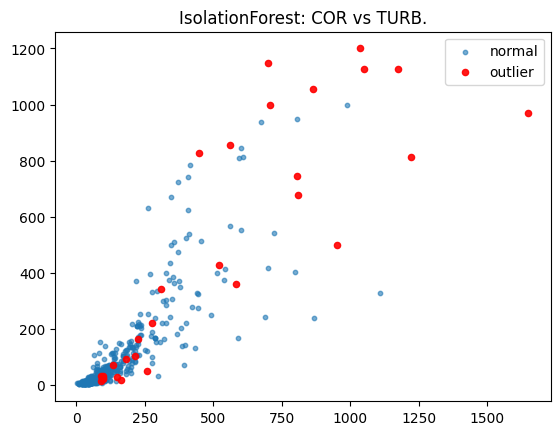

In [15]:
# Plotando os resultados

# amostras_normais = X[np.where(prediction > 0)]    # Não estão funcionando. O tutorial usa um pd.Series, então a indexação
# outliers = X[np.where(prediction < 0)]            # quebra em pd.DataFrame

amostras_normais = X.iloc[np.where(prediction > 0)[0]]  # iloc faz a indexação funcionar no pd.DataFrame 
outliers = X.iloc[np.where(prediction < 0)[0]]

plt.scatter(amostras_normais.iloc[:, 0],  # Seleciona a primeira coluna do dataframe
            amostras_normais.iloc[:, 1],  # Seleciona a segunda coluna
            s=10,   # Define um tamanho para os pontos normais. Será menor do que o dos outliers para facilitar visualização
            label='normal', 
            alpha=0.6  # Define opacidade dos pontos
            )  
plt.scatter(outliers.iloc[:, 0], outliers.iloc[:, 1], s=20, color='r', label='outlier', alpha=0.9)
plt.legend()
plt.title(f'IsolationForest: {variaveis[0]} vs {variaveis[1]}')
plt.show()

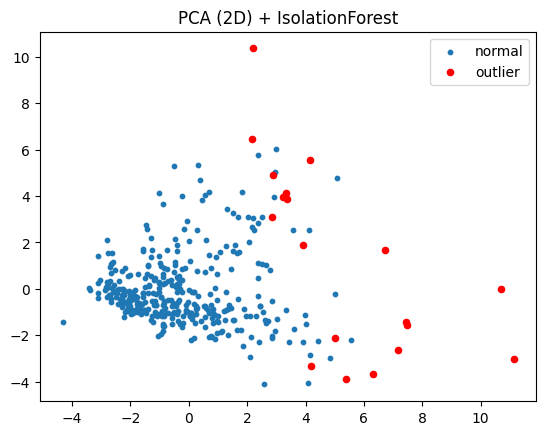

In [18]:
# Como há diversas variáveis, esses scatterplots de 2 dimensões seriam limitados.
# Entretanto, podemos usar PCA para reduzir todas as variáveis para 2 dimensões.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_nonan = X.dropna().copy() # PCA não funciona em dataframes com NaN

scaler = StandardScaler().fit(X_nonan)

X_scaled = scaler.transform(X_nonan)

pca = PCA(n_components=2).fit_transform(X_scaled)
pred = iforest.fit_predict(X_nonan)

plt.scatter(pca[pred > 0, 0], pca[pred > 0, 1], s=10, label='normal')
plt.scatter(pca[pred < 0, 0], pca[pred < 0, 1], s=20, color='r', label='outlier')
plt.legend()
plt.title('PCA (2D) + IsolationForest')
plt.show()

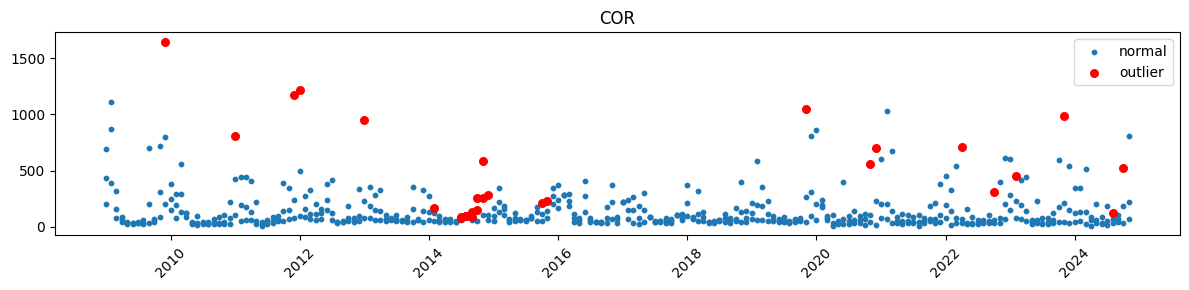

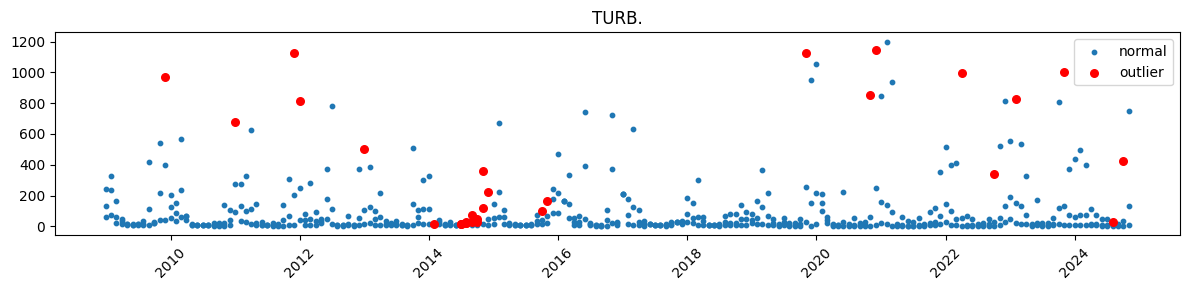

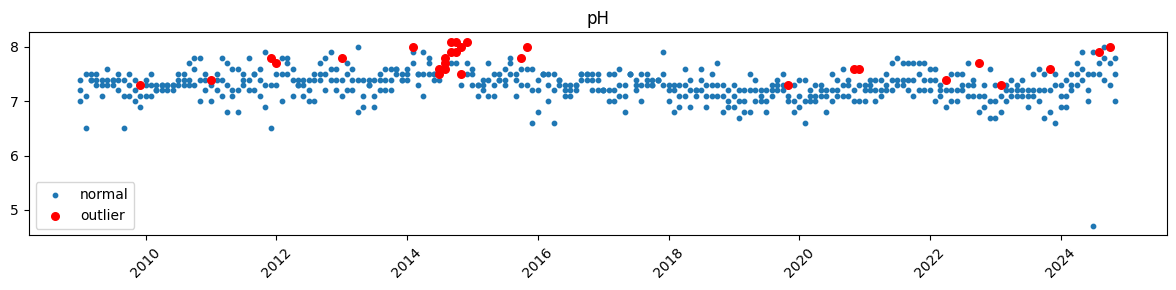

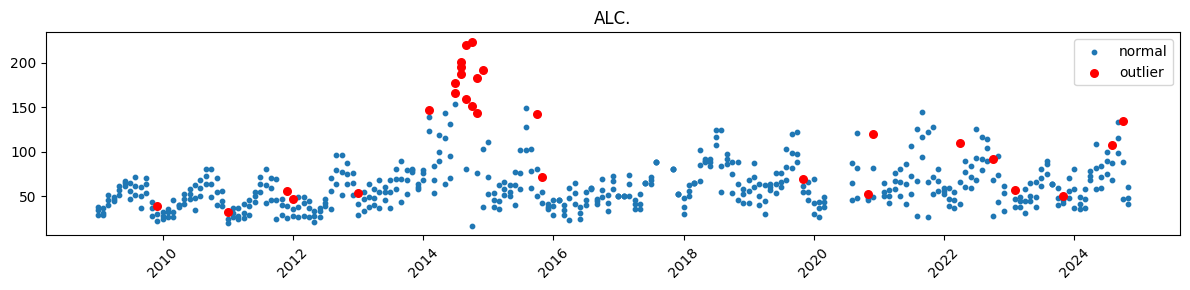

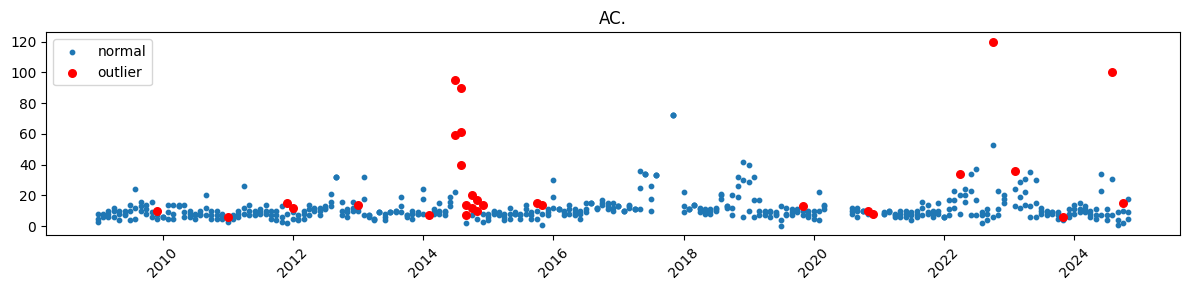

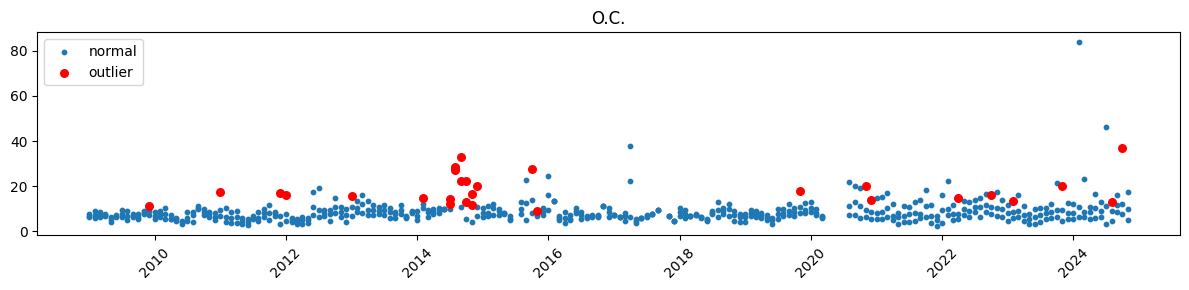

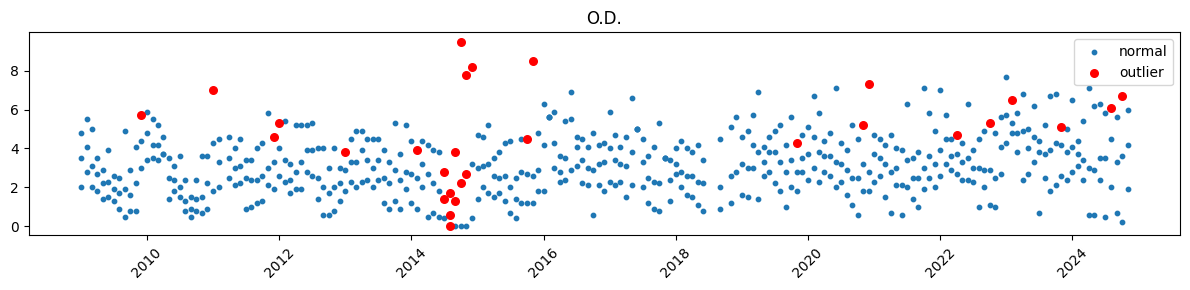

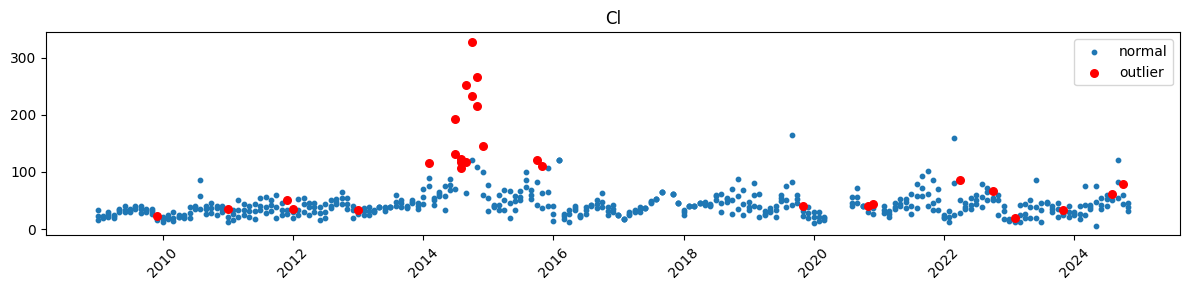

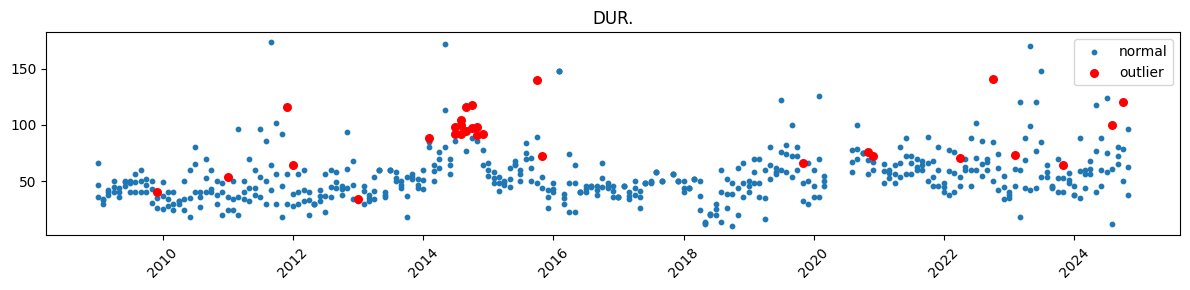

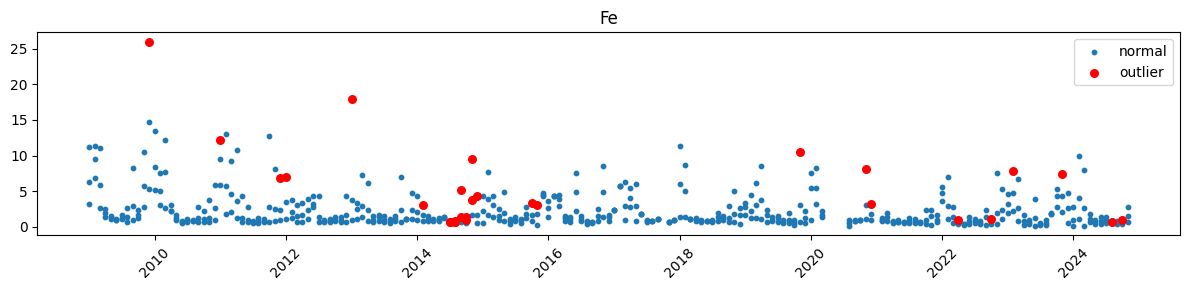

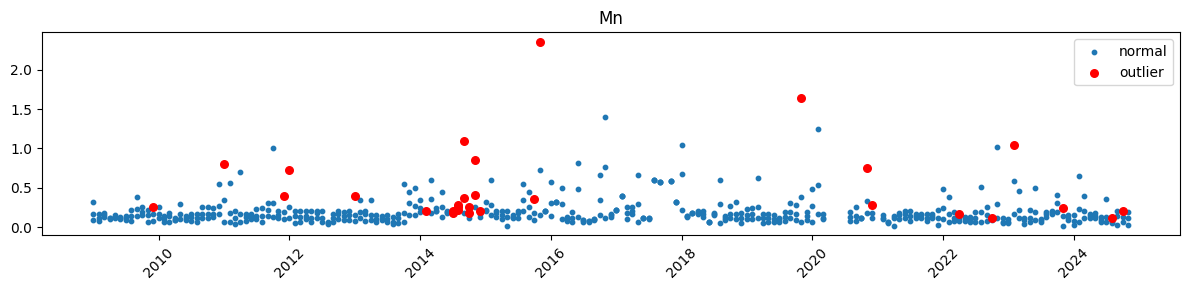

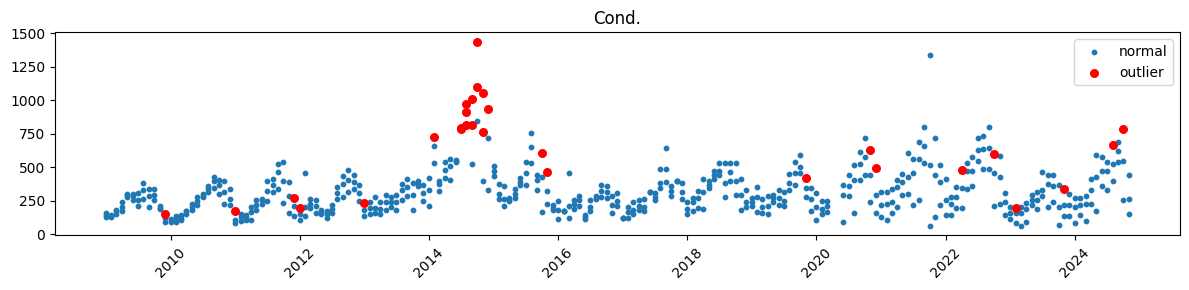

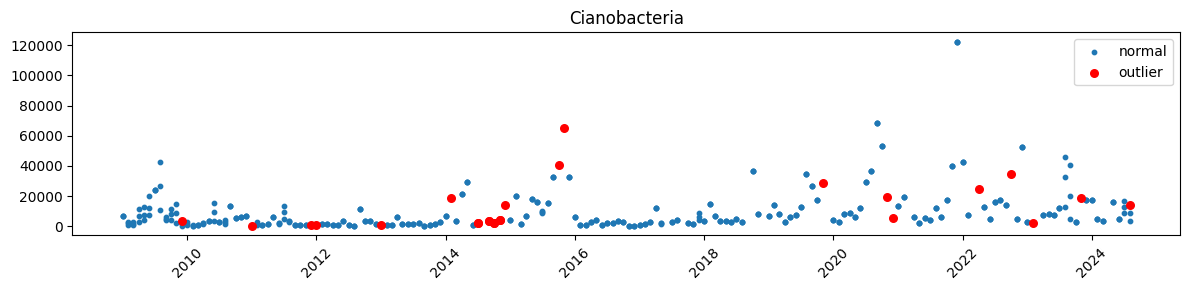

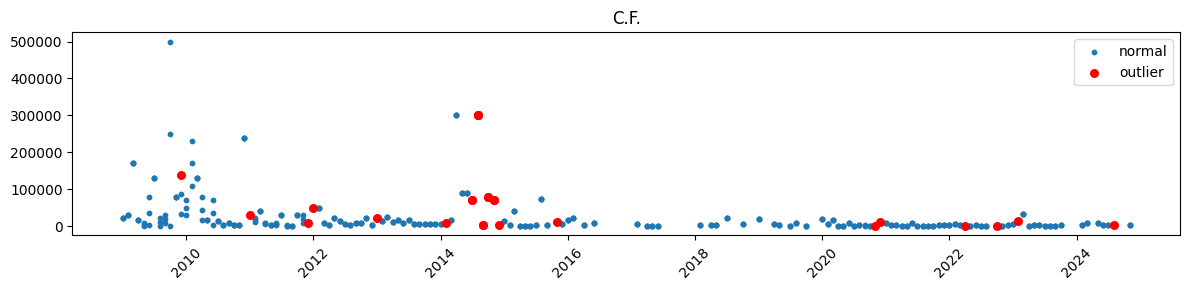

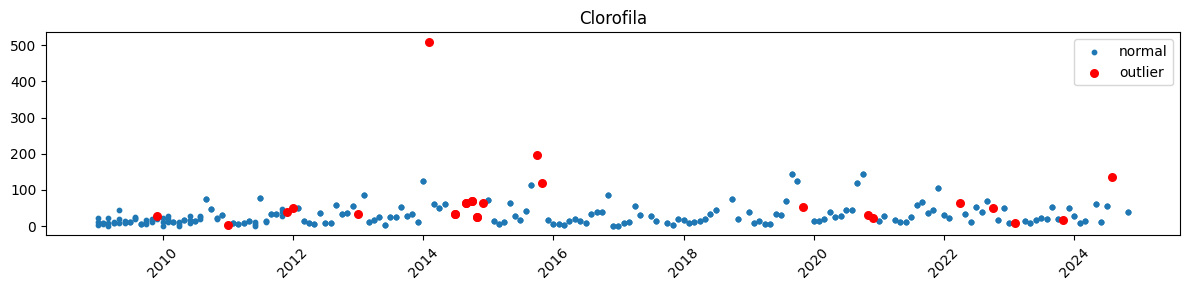

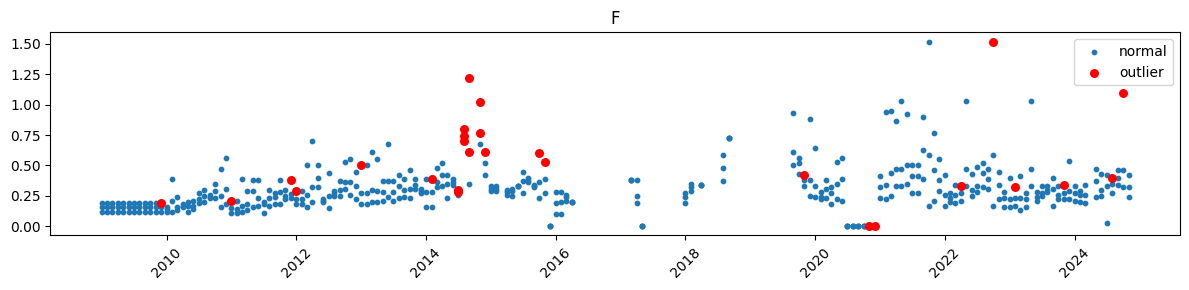

In [19]:
# Isolation Forest com série temporal. Gráficos individuais para cada variável

pred = iforest.fit_predict(X)

normal_idx = X.index[pred > 0]
outlier_idx = X.index[pred < 0]

for var in variaveis:
    plt.figure(figsize=(12, 3))
    plt.scatter(dados_limpos.loc[normal_idx, 'data_normalizada'],
                X.loc[normal_idx, var], s=10, label='normal')
    plt.scatter(dados_limpos.loc[outlier_idx, 'data_normalizada'],
                X.loc[outlier_idx, var], s=30, color='r', label='outlier')
    plt.title(var)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()